# Argentine Senate floor speech, 1998–2026

Analysis of the ar_congress corpus: 817 stenographic session transcripts
(versiones taquigráficas) published by the Senado de la Nación, parsed into
speaker-attributed speech turns and typed stenographer events, with speakers
resolved to persons. The portal serves the same URL in two formats depending
on the sitting's age — PDF from 2004, the chamber's own HTML export for most
of 1998–2003 — and the two are parsed by different readers (0.4.37 and
0.5.0-html) that share the speaker pattern and the event taxonomy, so a
passage means the same thing in either. Provenance and terms:
[SOURCES.md](../SOURCES.md).


In [1]:
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
BLOCKS = ROOT / "data" / "processed" / "senado" / "blocks"

# Only the columns this notebook reads. Naming them also keeps the per-sitting
# frames comparable: the HTML era has no page geometry, so `font` and `size` are
# empty there, and concatenating those columns across the two eras would make
# pandas guess at a dtype for a column nothing here uses.
COLUMNS = ["session_id", "session_date", "session_type", "type", "event_type",
           "speaker_raw", "text"]
corpus = pd.concat([pd.read_parquet(p, columns=COLUMNS)
                    for p in sorted(BLOCKS.glob("*.parquet"))], ignore_index=True)
speakers = pd.read_parquet(ROOT / "data" / "processed" / "senado" / "speakers.parquet")

speech = corpus[corpus.type == "speech"].merge(
    speakers[["session_id", "speaker_raw", "person_id", "person_name", "elected_ticket",
              "province", "match_status", "bloc", "bloc_status"]],
    on=["session_id", "speaker_raw"], how="left",
)
speech["words"] = speech.text.str.split().str.len()
speech["year"] = speech.session_date.str[:4].astype(int)
corpus["year"] = corpus.session_date.str[:4].astype(int)

# Years where the portal lists sittings it no longer serves, so the totals are
# a floor on what was said rather than a measurement of it. From 2002 on every
# sitting the portal lists is held.
PARTIAL_YEARS = range(1998, 2002)
# The corpus ends mid-September 2026, so that year is short for a reason that
# has nothing to do with the chamber.
YEAR_IN_PROGRESS = 2026
THIN = set(PARTIAL_YEARS) | {YEAR_IN_PROGRESS}


def shade_thin(ax):
    """Mark the years a per-year total cannot be read straight off."""
    ax.axvspan(min(PARTIAL_YEARS) - 0.5, max(PARTIAL_YEARS) + 0.5, color="#f2f2ef", zorder=0)
    ax.axvspan(YEAR_IN_PROGRESS - 0.5, YEAR_IN_PROGRESS + 0.5, color="#f2f2ef", zorder=0)


print(f"{corpus.session_id.nunique()} sessions | {len(corpus):,} rows | "
      f"{len(speech):,} speech turns | {speech.words.sum():,} words spoken")


817 sessions | 440,445 rows | 244,625 speech turns | 25,286,822 words spoken


## Sampling frame — read this before trusting any trend

The corpus is **not** a neutral sample of Senate activity, and the
distortions are large enough to invent trends on their own:

- **Holdings are complete from 2002 and partial before it.** The portal
  lists sittings it no longer serves for the four earliest years: 51 of 73
  held for 1998, 47 of 74 for 1999, 46 of 75 for 2000, 44 of 83 for 2001.
  From 2002 on, every sitting the portal lists is held. Those four years are
  shaded in the charts and dropped from every rate. The portal lists sittings
  back to 1983, but of the 882 it lists before 1998 exactly one is still
  served — established by asking for all 882, not by sampling.
- **2026 is a year in progress.** The corpus ends on 17 September 2026, so
  that year's totals are short for a reason that has nothing to do with the
  chamber. It is shaded like the partial years.
- **Session counts swing with the political calendar**, from 51 sittings in
  1998 to 12 in the 2023 election year, so a fall in yearly word totals can
  mean fewer sittings rather than less speech. Both are shown separately.
- **Asambleas Legislativas are not Senate debate** — they are joint sittings
  where the President of the Nation speaks. They stay in the corpus but are
  excluded from every floor-speech figure here.
- **Alliance ≠ caucus.** The historic roster records the *electoral alliance*
  each senator was elected under, not the bloc they sat with. The two diverge
  sharply after 2015: radicals elected on Cambiemos and Juntos por el Cambio
  tickets appear under those labels and not under the UCR. Both readings are
  given below, side by side.
- **The caucus does not reach 1998–1999.** It is observed, never continuous,
  and the earliest observation is the Internet Archive's capture of the
  Senate's bloc-roster page on 25 May 2000. Those two years therefore have
  the ticket and nothing else.


In [2]:
overview = (corpus.groupby(["year", "session_type"]).session_id.nunique()
            .unstack(fill_value=0))
overview["total"] = overview.sum(axis=1)
overview

session_type,ASAMBLEA,EN MINORÍA,ESPECIAL,ESPECIAL EN MINORÍA,ESPECIAL EXTRAORDINARIA,EXTRAORDINARIA,FALTA DE QUORUM,INFORMATIVA ESPECIAL,ORDINARIA,ORDINARIA CONTINUACIÓN,PREPARATORIA,REUNIÓN CONJ.AMBAS CÁMARAS,TRIBUNAL DE JUICIO POLITICO,total
year,,,,,,,,,,,,,,
1998,1,5,4,0,0,1,0,0,36,1,1,1,1,51
1999,3,6,7,0,0,2,0,0,28,0,1,0,0,47
2000,2,0,5,0,0,5,0,0,32,0,1,1,0,46
2001,4,4,4,0,0,3,0,0,27,0,2,0,0,44
2002,2,3,10,0,0,2,0,0,29,0,1,0,0,47
2003,5,0,3,0,0,1,0,0,23,0,1,0,13,46
2004,2,1,3,0,0,1,0,0,30,0,1,0,2,40
2005,1,0,2,0,0,5,0,0,24,0,1,0,13,46
2006,2,0,2,0,0,2,0,0,29,0,1,0,0,36


## Who holds the floor?

**Floor speech** here means: speech turns by senators speaking from the
floor (`match_status == "matched_senator"`), outside Asambleas. Chair and
officer speech is excluded as procedural — the presiding officer's "Tiene
la palabra..." traffic would otherwise swamp every signal.

Alliances are grouped into four **party families** by the keyword rules in
the next cell — auditable and deliberately coarse, so that one bucket can
hold a party and the coalitions it later ran inside. Provincial alliances
(Movimiento Popular Neuquino, Cruzada Renovadora de San Juan, Juntos Somos
Río Negro, ...) stay in their own bucket even where their senators caucus
with a national bloc.

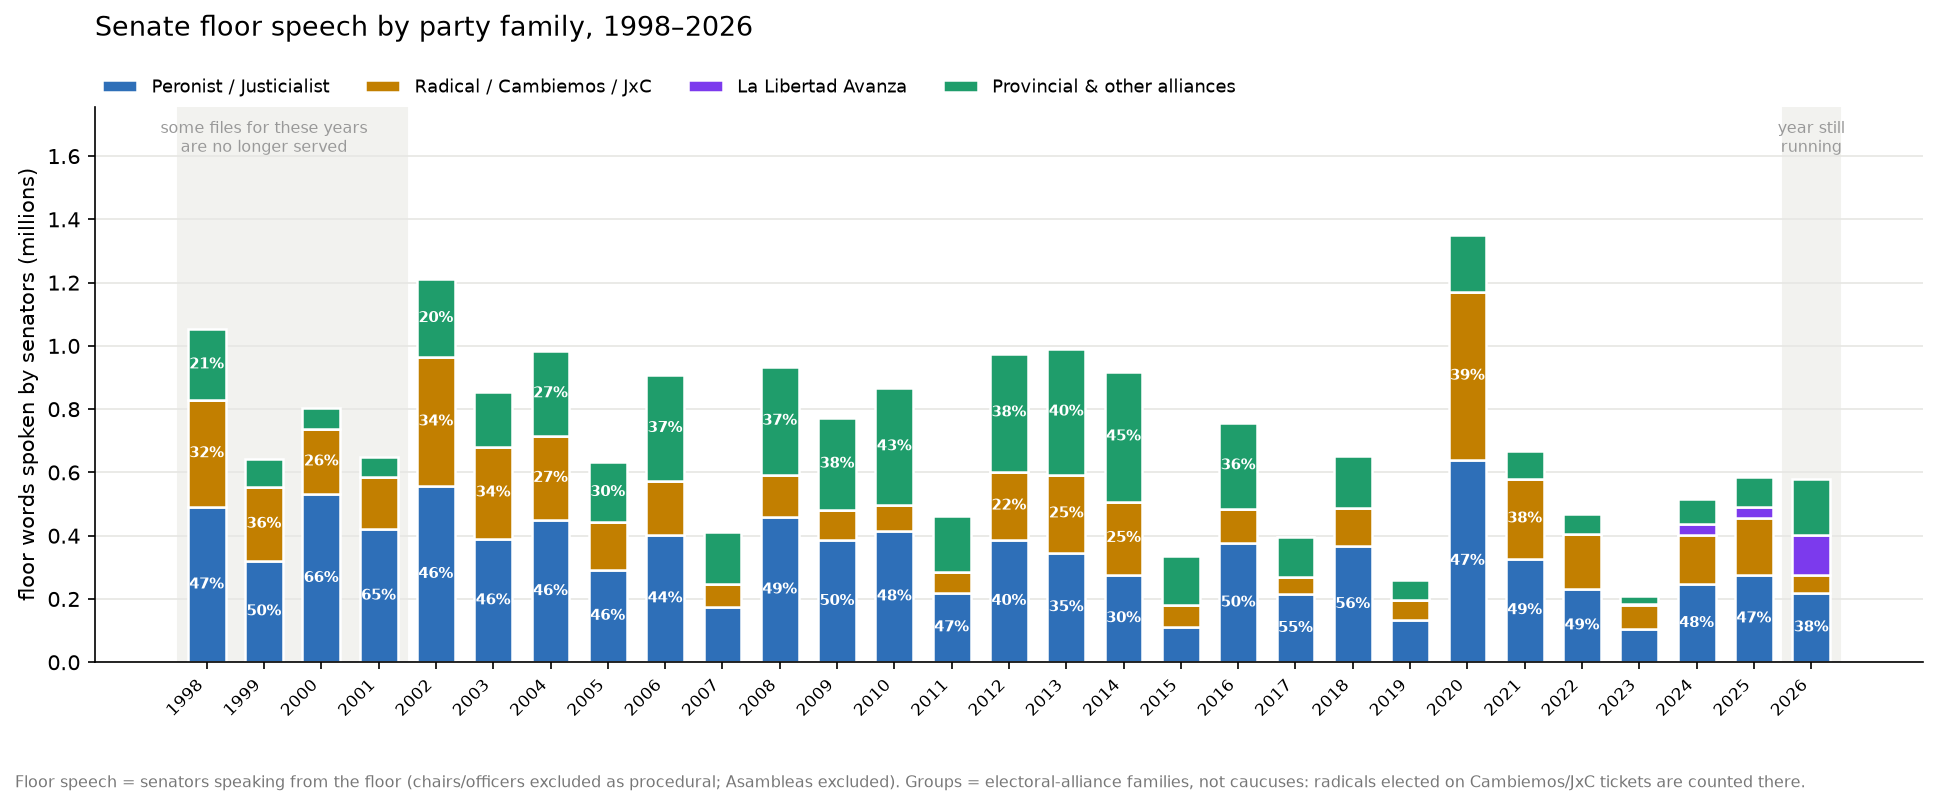

family,Peronist / Justicialist,Radical / Cambiemos / JxC,La Libertad Avanza,Provincial & other alliances
year,,,,
1998,0.490,0.340,0.000,0.222
1999,0.320,0.233,0.000,0.090
2000,0.531,0.205,0.000,0.067
2001,0.420,0.165,0.000,0.065
2002,0.557,0.407,0.000,0.247
2003,0.390,0.292,0.000,0.173
2004,0.448,0.268,0.000,0.267
2005,0.292,0.150,0.000,0.190
2006,0.403,0.170,0.000,0.334


In [3]:
def deaccent(s):
    return "".join(c for c in unicodedata.normalize("NFD", s) if not unicodedata.combining(c))

def family(alliance):
    """Group an electoral-alliance label into a party family.

    Order matters: the era-specific coalition labels are tested first, so a
    radical elected on a Cambiemos ticket lands with Cambiemos — which is
    what the ballot said — rather than with the UCR.
    """
    a = deaccent(str(alliance or "")).upper()
    if "LIBERTAD AVANZA" in a:
        return "La Libertad Avanza"
    if "CAMBIEMOS" in a or "JUNTOS POR EL CAMBIO" in a or "CIVICA RADICAL" in a or "UCR" in a:
        return "Radical / Cambiemos / JxC"
    if any(k in a for k in ("JUSTICIALIS", "PERONIS", "PARA LA VICTORIA", "DE LA VICTORIA",
                            "P/VICTORIA", "DE TODOS", "UNIDAD CIUDADANA", "UNION POR LA PATRIA")):
        return "Peronist / Justicialist"
    return "Provincial & other alliances"

floor = speech[(speech.match_status == "matched_senator") & (speech.session_type != "ASAMBLEA")].copy()
floor["family"] = floor.elected_ticket.map(family)

ORDER = ["Peronist / Justicialist", "Radical / Cambiemos / JxC",
         "La Libertad Avanza", "Provincial & other alliances"]
COLORS = {"Peronist / Justicialist": "#2E6FB8", "Radical / Cambiemos / JxC": "#C27F00",
          "La Libertad Avanza": "#7C3AED", "Provincial & other alliances": "#1F9D6B"}

by_year = (floor.groupby(["year", "family"]).words.sum().unstack(fill_value=0)
           .reindex(columns=ORDER, fill_value=0) / 1e6)

fig, ax = plt.subplots(figsize=(13.0, 5.0), dpi=150)
shade_thin(ax)
tallest = by_year.sum(axis=1).max()
ax.set_ylim(0, tallest * 1.30)
ax.text(sum(PARTIAL_YEARS) / len(PARTIAL_YEARS) - 0.5, tallest * 1.27,
        "some files for these years\nare no longer served",
        fontsize=7.5, color="#999999", ha="center", va="top")
ax.text(YEAR_IN_PROGRESS, tallest * 1.27, "year still\nrunning",
        fontsize=7.5, color="#999999", ha="center", va="top")

bottom = pd.Series(0.0, index=by_year.index)
for col in ORDER:
    ax.bar(by_year.index, by_year[col], bottom=bottom, width=0.66,
           color=COLORS[col], edgecolor="white", linewidth=1.2, label=col, zorder=2)
    seg = by_year[col]
    for x, (y0, h) in zip(by_year.index, zip(bottom, seg)):
        if h > 0.14 * by_year.sum(axis=1).max():
            ax.text(x, y0 + h / 2, f"{h / by_year.sum(axis=1)[x]:.0%}", ha="center", va="center",
                    color="white", fontsize=7, fontweight="bold", zorder=3)
    bottom += seg

ax.set_title("Senate floor speech by party family, 1998–2026",
             fontsize=13, loc="left", pad=34)
ax.set_ylabel("floor words spoken by senators (millions)")
ax.set_xticks(list(by_year.index))
ax.set_xticklabels(by_year.index, rotation=45, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f"))
ax.grid(axis="y", color="#e6e6e3", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
# the legend runs along the top rather than inside the axes, which at 29 bars
# leaves no free corner
ax.legend(frameon=False, fontsize=8.5, ncol=4, loc="lower left",
          bbox_to_anchor=(0, 1.005), borderaxespad=0)
fig.text(0.01, -0.06,
         "Floor speech = senators speaking from the floor (chairs/officers excluded as procedural; Asambleas excluded). "
         "Groups = electoral-alliance families, not caucuses: radicals elected on Cambiemos/JxC tickets are counted there.",
         fontsize=7.5, color="#777777")
fig.tight_layout()
fig.savefig(ROOT / "figures" / "floor_words_by_year.png", bbox_inches="tight")
plt.show()

by_year.round(3)


## The same floor, grouped by caucus instead of by ticket

Every bar above groups senators by the **ticket they were elected on**, because
that is the only affiliation the historic roster carries. It is not the caucus
they sat with, and the difference is the single largest caveat on this notebook.

The caucus comes from `speakers.parquet`, which carries for every resolved
senator the caucus observed nearest that sitting, how far away that observation
was, and how far it can be trusted. Two sources feed it: the Senate's roll-call
records, which publish the whole chamber with each senator's caucus beside their
name, from February 2005; and sixteen Internet Archive captures of the Senate's
own bloc-roster page, reaching back to 25 May 2000, which cover the years the
roll calls do not. Caucus names are filed under the same four families used
above.

**The Senate dates the caucus wrong in one specific way, and the question is
whether that matters here.** It re-labels old roll calls with the caucus a
senator joined later: Frente de Todos, formed in December 2019, is stamped on
votes back to 2010. Every reading is checked against that caucus's own dated
life in `blocs_manual.csv` and marked `anachronistic` where the name did not
yet exist. Dropping those rows is the cautious move and it is the wrong one
here, because what they get wrong is the NAME and this panel reads the FAMILY.
The cell below checks that rather than asserting it: it compares every
anachronistic reading against the same senator's nearest attested one and
reports how often the family differs. It is 1.4% of them. Dropping them instead
would cost 40% of the evidence in 2018–2019 — and not at random, since the
readings the Senate back-labels are overwhelmingly peronist ones, so the cure
would bias the panel against the family it mislabels.


back-labelled readings: 15,463 passages; 153 (1.0%) name a DIFFERENT family from the same senator's nearest attested reading


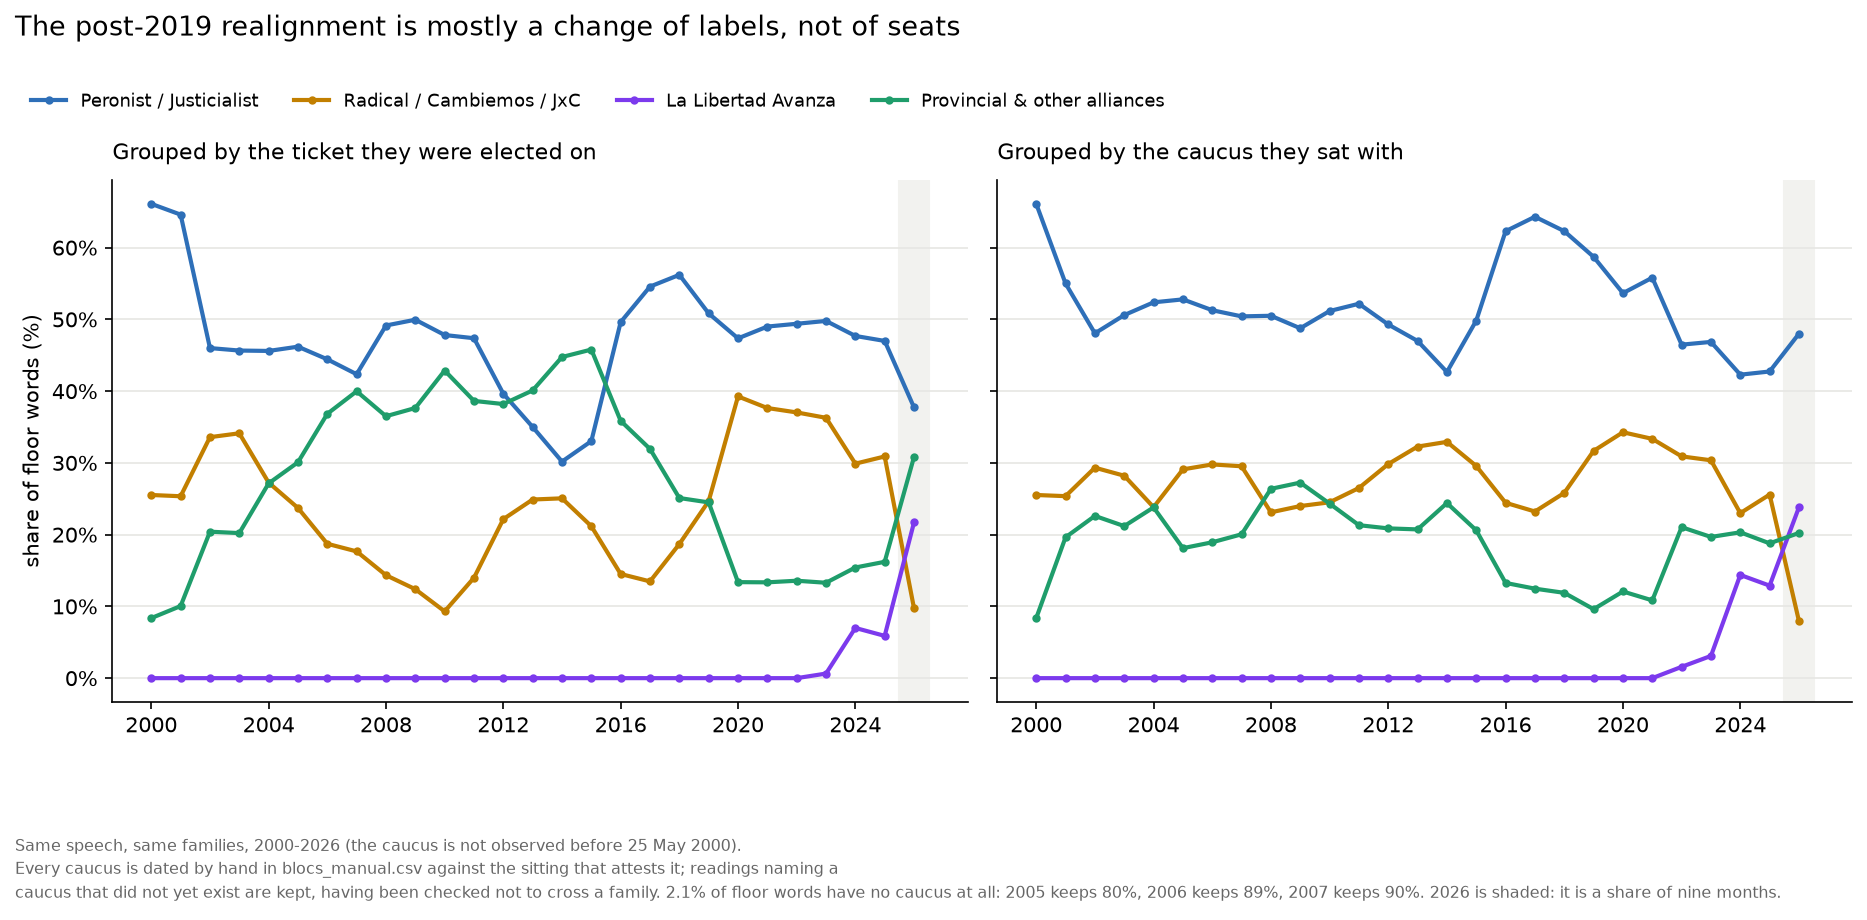

Grouped by the ticket they were elected on
   Provincial & other alliances   8-46% to 2018, 13-24% 2019-2025, 31% in 2026
   Radical / Cambiemos / JxC      9-34% to 2018, 25-39% 2019-2025, 10% in 2026
   Peronist / Justicialist        30-66% to 2018, 47-51% 2019-2025, 38% in 2026
Grouped by the caucus they sat with
   Provincial & other alliances   8-27% to 2018, 10-21% 2019-2025, 20% in 2026
   Radical / Cambiemos / JxC      23-33% to 2018, 23-34% 2019-2025, 8% in 2026
   Peronist / Justicialist        43-66% to 2018, 42-59% 2019-2025, 48% in 2026


In [4]:
# The caucus each speech turn's senator sat with, filed under the same families.
# bloque_observado.csv carries the family for every caucus name it records; the
# mapping is one-to-one, checked here rather than assumed.
obs = pd.read_csv(ROOT / "reference" / "senado" / "bloque_observado.csv")
assert obs.groupby("bloque").familia.nunique().max() == 1, "a caucus name spans two families"
BLOC_FAMILY = obs.drop_duplicates("bloque").set_index("bloque").familia.to_dict()

caucus = floor[floor.year >= 2000].copy()
caucus["caucus_family"] = caucus.bloc.map(BLOC_FAMILY)
unplaced = 1 - caucus.caucus_family.notna().mul(caucus.words).sum() / caucus.words.sum()

# Does the Senate's back-labelling reach across a family boundary? For every
# reading marked anachronistic, compare it with the nearest reading of the same
# senator that IS attested for its date. If those agree, the wrong name is
# still the right side of the chamber and the row belongs in this panel.
attested = speakers[(speakers.bloc_status == "confirmed") & speakers.person_id.notna()].copy()
attested["fam"] = attested.bloc.map(BLOC_FAMILY)
attested["when"] = pd.to_datetime(attested.session_date)
nearest = {pid: g.sort_values("when")[["when", "fam"]].values.tolist()
           for pid, g in attested.groupby("person_id")}

def nearest_attested_family(person_id, when):
    runs = nearest.get(person_id)
    if not runs:
        return None
    return min(runs, key=lambda r: abs((r[0] - pd.Timestamp(when)).days))[1]

late = speakers[(speakers.bloc_status == "anachronistic") & speakers.person_id.notna()].copy()
late["fam"] = late.bloc.map(BLOC_FAMILY)
late["near"] = [nearest_attested_family(p, d) for p, d in zip(late.person_id, late.session_date)]
crosses = late[late.near.notna() & (late.near != late.fam)].n_blocks.sum()
print(f"back-labelled readings: {late.n_blocks.sum():,} passages; "
      f"{crosses:,} ({crosses / late.n_blocks.sum():.1%}) name a DIFFERENT family "
      f"from the same senator's nearest attested reading")

coverage = (caucus.assign(ok=caucus.caucus_family.notna())
            .groupby("year").apply(lambda d: d[d.ok].words.sum() / d.words.sum(),
                                   include_groups=False)) * 100
worst = coverage.nsmallest(3).sort_index()


def share(frame, col):
    t = frame.groupby(["year", col]).words.sum().unstack(fill_value=0)
    t = t.reindex(columns=ORDER, fill_value=0)
    return t.div(t.sum(axis=1), axis=0) * 100


panels = [("Grouped by the ticket they were elected on", share(caucus, "family")),
          ("Grouped by the caucus they sat with", share(caucus.dropna(subset=["caucus_family"]),
                                                        "caucus_family"))]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), dpi=150, sharey=True)
for ax, (title, tbl) in zip(axes, panels):
    # 2026 is a share of nine months, so it is marked rather than dropped
    ax.axvspan(YEAR_IN_PROGRESS - 0.5, YEAR_IN_PROGRESS + 0.5, color="#f2f2ef", zorder=0)
    for col in ORDER:
        ax.plot(tbl.index, tbl[col], color=COLORS[col], linewidth=2.0,
                marker="o", markersize=3, label=col, zorder=2)
    ax.set_title(title, fontsize=10.5, loc="left", pad=10)
    ax.set_xticks(range(2000, 2027, 4))
    ax.grid(axis="y", color="#e6e6e3", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
axes[0].set_ylabel("share of floor words (%)")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
handles, names = axes[0].get_legend_handles_labels()
fig.legend(handles, names, frameon=False, fontsize=8.5, ncol=4,
           loc="upper left", bbox_to_anchor=(0.008, 0.99))
fig.suptitle("The post-2019 realignment is mostly a change of labels, not of seats",
             fontsize=13, x=0.008, ha="left", y=1.08)
fig.text(0.008, -0.20,
         "Same speech, same families, 2000-2026 (the caucus is not observed before 25 May 2000).\n"
         "Every caucus is dated by hand in blocs_manual.csv against the sitting that attests it; readings naming a\n"
         f"caucus that did not yet exist are kept, having been checked not to cross a family. {unplaced:.1%} of floor "
         "words have no caucus at all: " + ", ".join(f"{y} keeps {v:.0f}%" for y, v in worst.items())
         + ". 2026 is shaded: it is a share of nine months.",
         fontsize=7.5, color="#666666", linespacing=1.5)
fig.tight_layout()
fig.savefig(ROOT / "figures" / "ticket_vs_caucus.png", bbox_inches="tight")
plt.show()

for label, tbl in panels:
    print(label)
    for col in ("Provincial & other alliances", "Radical / Cambiemos / JxC", "Peronist / Justicialist"):
        v = tbl[col]
        # 2026 apart: it is nine months, and the year La Libertad Avanza arrives
        print(f"   {col:<30} {v.loc[2000:2018].min():.0f}-{v.loc[2000:2018].max():.0f}% to 2018,"
              f" {v.loc[2019:2025].min():.0f}-{v.loc[2019:2025].max():.0f}% 2019-2025,"
              f" {v.loc[2026]:.0f}% in 2026")


## Fewer sittings, or shorter ones?

A yearly total mixes two different things: how often the chamber sat and
how much was said when it did. Separating them changes the reading of the
2020–2023 fall — and shows that 2020, the remote-procedure year, was
extraordinary in the number of sittings rather than in their length.


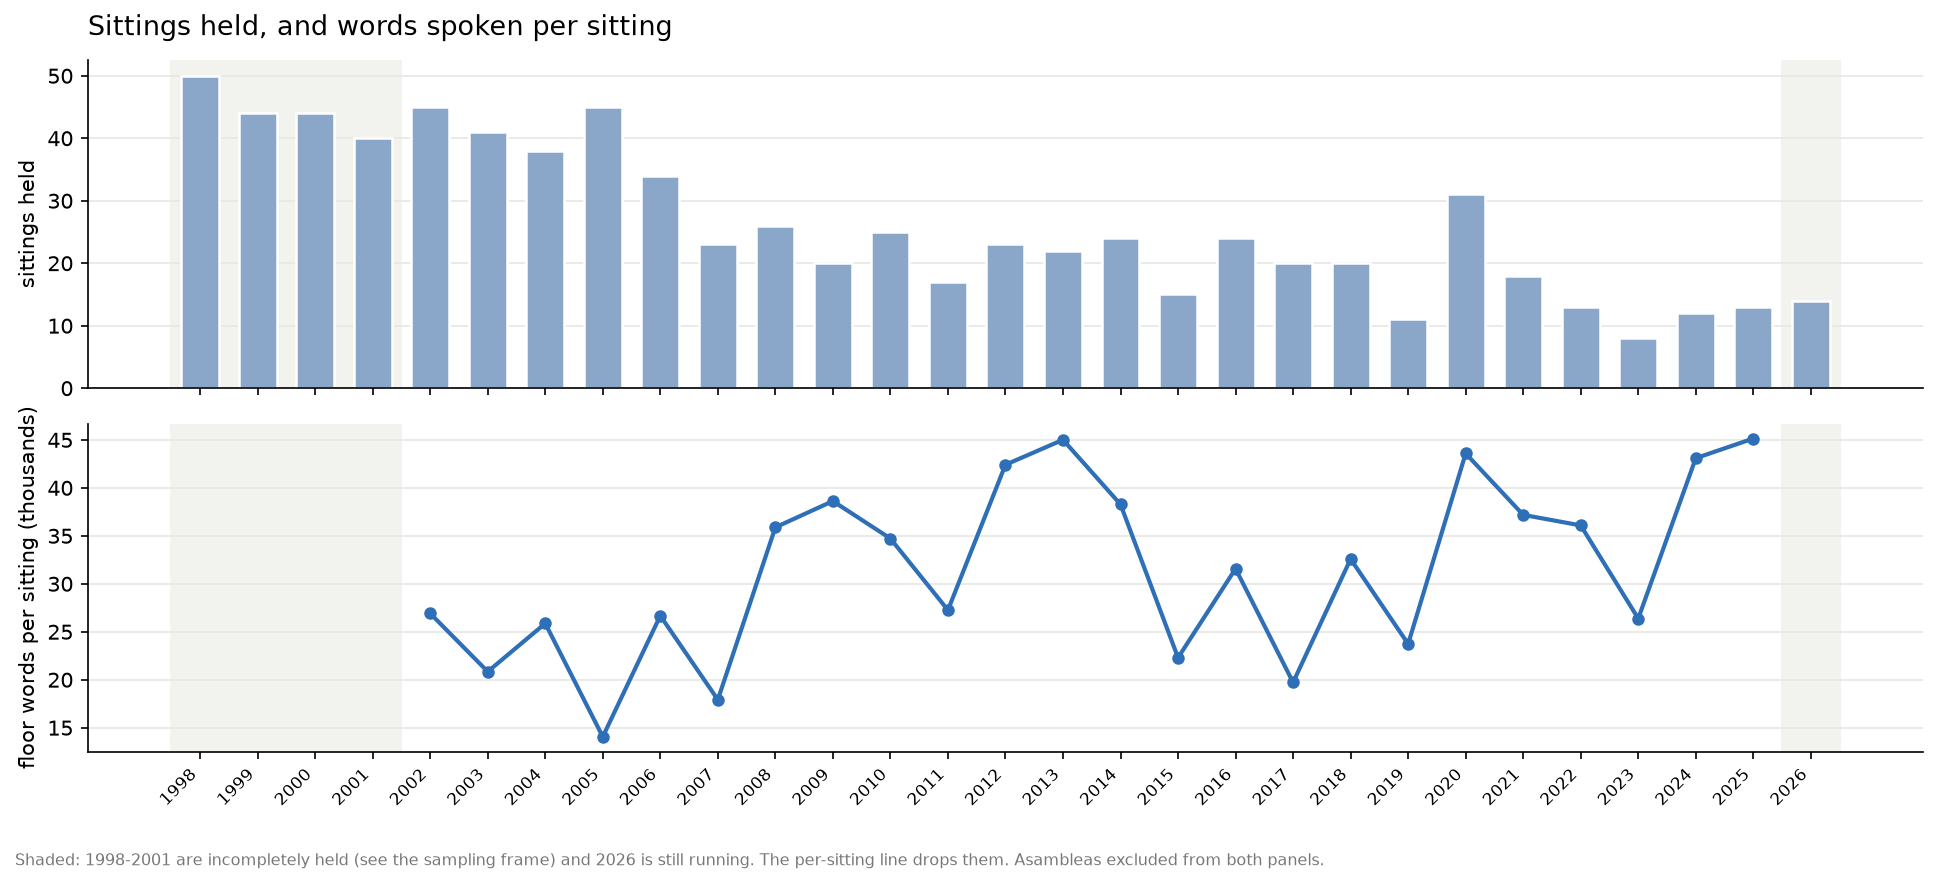

year,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
sittings,50.0,44.0,44.0,40.0,45.0,41.0,38.0,45.0,34.0,23.0,...,20.0,20.0,11.0,31.0,18.0,13.0,8.0,12.0,13.0,14.0
words per sitting,21038.0,14629.0,18273.0,16242.0,26912.0,20843.0,25868.0,14056.0,26672.0,17917.0,...,19722.0,32583.0,23729.0,43587.0,37184.0,36086.0,26380.0,43093.0,45142.0,41440.0


In [5]:
sessions_held = (corpus[corpus.session_type != "ASAMBLEA"]
                 .groupby("year").session_id.nunique())
words_year = floor.groupby("year").words.sum()
per_session = (words_year / sessions_held).dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13.0, 5.6), dpi=150, sharex=True)
full = [y for y in per_session.index if y not in THIN]

ax1.bar(sessions_held.index, sessions_held.values, width=0.66, color="#8AA6C8",
        edgecolor="white", linewidth=1.2, zorder=2)
ax1.set_ylabel("sittings held")
ax1.set_title("Sittings held, and words spoken per sitting", fontsize=13, loc="left", pad=12)

ax2.plot(full, per_session.reindex(full).values / 1000, marker="o", markersize=5,
         linewidth=2, color="#2E6FB8", zorder=2)
ax2.set_ylabel("floor words per sitting (thousands)")
ax2.set_xticks(list(sessions_held.index))
ax2.set_xticklabels(sessions_held.index, rotation=45, ha="right", fontsize=8)

for ax in (ax1, ax2):
    shade_thin(ax)
    ax.grid(axis="y", color="#e6e6e3", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.text(0.01, -0.04,
         "Shaded: 1998-2001 are incompletely held (see the sampling frame) and 2026 is still running. "
         "The per-sitting line drops them. Asambleas excluded from both panels.",
         fontsize=7.5, color="#777777")
fig.tight_layout()
fig.savefig(ROOT / "figures" / "sittings_and_length.png", bbox_inches="tight")
plt.show()

pd.DataFrame({"sittings": sessions_held, "words per sitting": per_session.round(0)}).T


## Chamber temperature

The stenographer events the parser preserves allow something
transcripts-as-text cannot: measuring what happened *around* the words.
Rates are per 10,000 floor words, so a quiet year does not masquerade as a
calm one. The incompletely held years and the year still running are
dropped — their denominators are not comparable.


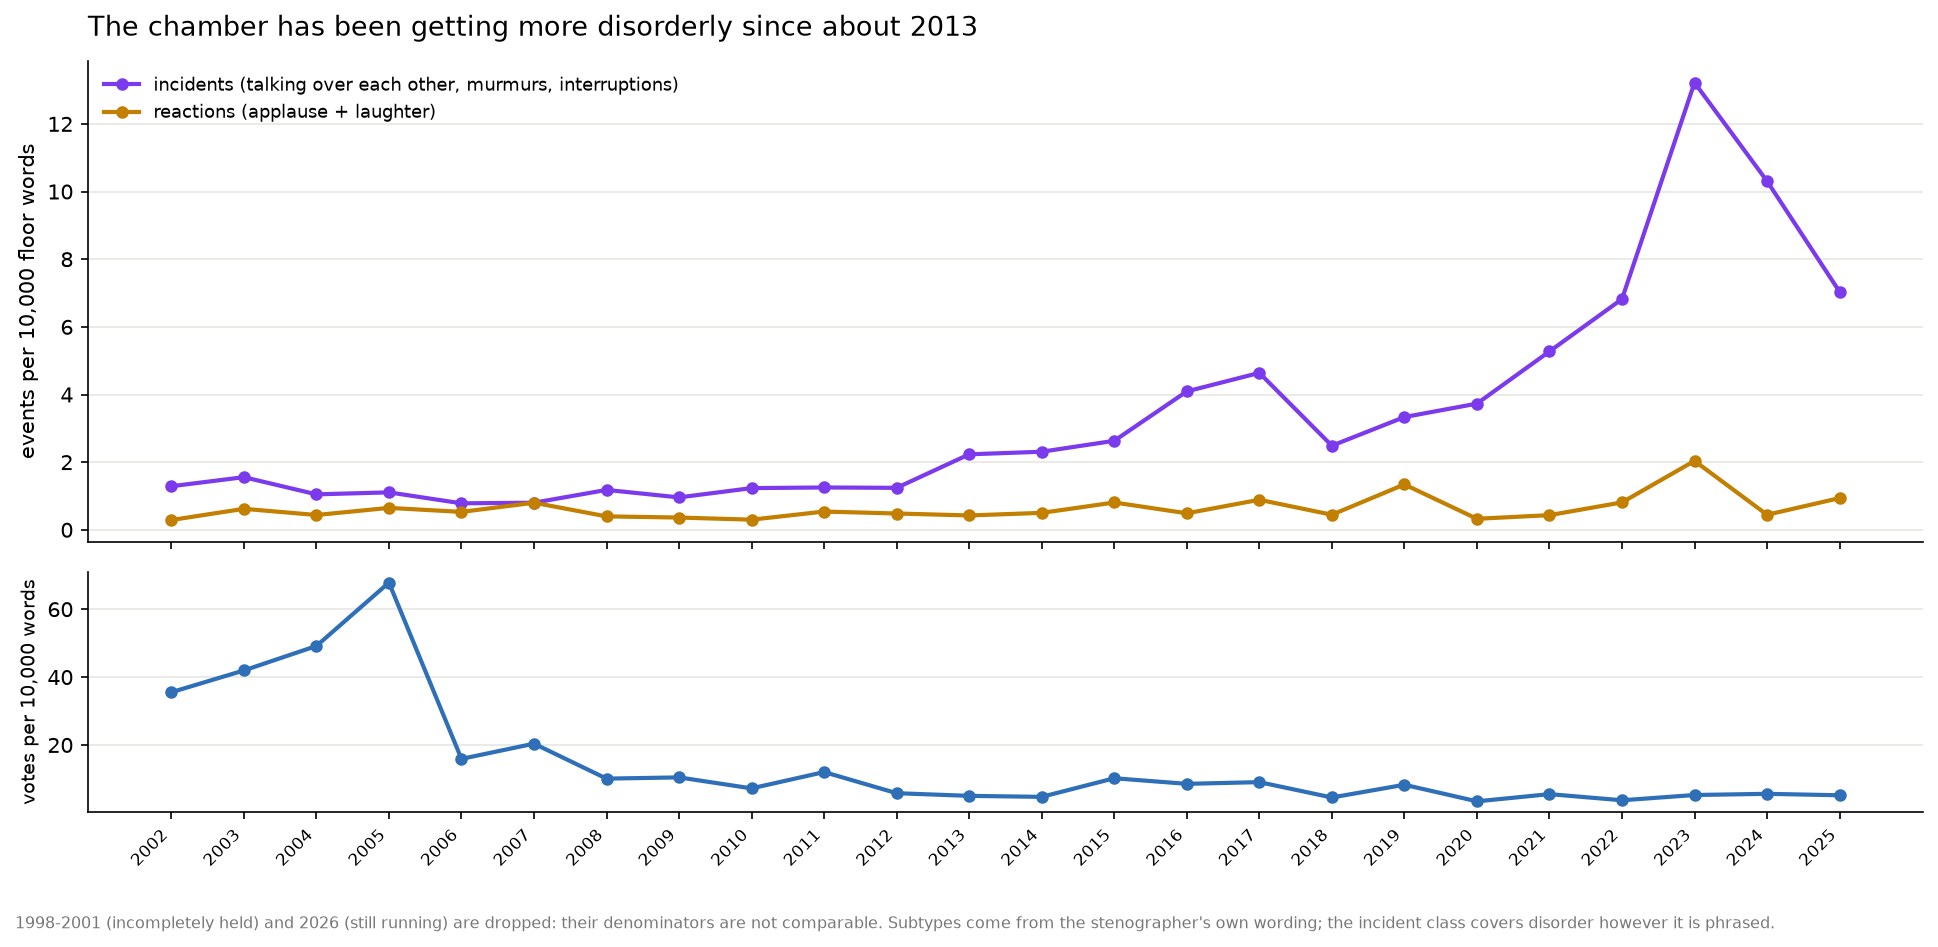

,incidents,reactions,votes
year,,,
2002,1.3,0.3,35.5
2003,1.6,0.6,42.0
2004,1.0,0.4,49.2
2005,1.1,0.6,67.8
2006,0.8,0.5,15.9
2007,0.8,0.8,20.4
2008,1.2,0.4,10.1
2009,1.0,0.4,10.4
2010,1.2,0.3,7.2


In [6]:
events = corpus[(corpus.type == "event") & (corpus.session_type != "ASAMBLEA")]
fw = floor.groupby("year").words.sum()
fw = fw[[y for y in fw.index if y not in THIN]]

def rate(subtypes):
    n = events[events.event_type.isin(subtypes)].groupby("year").size()
    return (n / fw * 10_000).reindex(fw.index)

# Votes sit an order of magnitude above the rest and would flatten them on a
# shared axis, so they get their own panel: procedural volume, not temperature.
TEMP = {"incidents (talking over each other, murmurs, interruptions)": (["incident"], "#7C3AED"),
        "reactions (applause + laughter)": (["applause", "laughter"], "#C27F00")}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13.0, 6.0), dpi=150, sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
for name, (subtypes, colour) in TEMP.items():
    r = rate(subtypes)
    ax1.plot(r.index, r.values, marker="o", markersize=5, linewidth=2, color=colour, label=name)
ax1.set_ylabel("events per 10,000 floor words")
ax1.set_title("The chamber has been getting more disorderly since about 2013",
              fontsize=13, loc="left", pad=12)
ax1.legend(frameon=False, fontsize=8.5, loc="upper left")

votes = rate(["vote"])
ax2.plot(votes.index, votes.values, marker="o", markersize=5, linewidth=2, color="#2E6FB8")
ax2.set_ylabel("votes per 10,000 words", fontsize=9)
ax2.set_xticks(list(fw.index))
ax2.set_xticklabels(fw.index, rotation=45, ha="right", fontsize=8)

for ax in (ax1, ax2):
    ax.grid(axis="y", color="#e6e6e3", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.text(0.01, -0.04,
         "1998-2001 (incompletely held) and 2026 (still running) are dropped: their denominators are not comparable. "
         "Subtypes come from the stenographer's own wording; the incident class covers disorder however it is phrased.",
         fontsize=7.5, color="#777777")
fig.tight_layout()
fig.savefig(ROOT / "figures" / "chamber_temperature.png", bbox_inches="tight")
plt.show()

pd.DataFrame({"incidents": rate(["incident"]), "reactions": rate(["applause", "laughter"]),
              "votes": votes}).round(1)


## Who spoke most, over twenty-nine years


In [7]:
span = floor.groupby("person_name").year.agg(["min", "max"])
top = (floor.groupby(["person_name", "province"]).words.sum()
       .sort_values(ascending=False).head(15) / 1000).round(1).rename("floor words (thousands)")
top = top.reset_index().merge(span, left_on="person_name", right_index=True)
top["years on the floor"] = top["min"].astype(str) + "–" + top["max"].astype(str)
top[["person_name", "province", "floor words (thousands)", "years on the floor"]]

,person_name,province,floor words (thousands),years on the floor
0,"MORALES, GERARDO RUBÉN",JUJUY,828.6,2001–2015
1,"PICHETTO, MIGUEL ÁNGEL",RÍO NEGRO,806.5,2001–2019
2,"MAYANS, JOSÉ MIGUEL ÁNGEL",FORMOSA,593.5,2001–2026
3,"NEGRE DE ALONSO, LILIANA TERESITA",SAN LUIS,526.5,2001–2017
4,"PETCOFF NAIDENOFF, LUIS CARLOS",FORMOSA,449.7,2005–2023
5,"SANZ, ERNESTO RICARDO",MENDOZA,409.3,2003–2015
6,"GIUSTINIANI, RUBÉN HÉCTOR",SANTA FE,395.0,2003–2015
7,"YOMA, JORGE RAÚL",LA RIOJA,392.7,1998–2005
8,"CAPITANICH, JORGE MILTON",CHACO,391.7,2001–2026
9,"MENEM, EDUARDO",LA RIOJA,347.5,1998–2005


## Findings

1. **The Peronist/Justicialist family has been the largest on the floor in 21
   of the 24 completely held years.** Its share of floor words runs from 30% to
   56%, median 47%, across five changes of national government. The three
   exceptions — 2013, 2014 and 2015, where the residual provincial-and-other
   bucket is larger — turn out to be an artefact of grouping by ticket: regroup
   the same speech by the caucus each senator sat in and the peronist family is
   the largest in **every one of the twenty-seven years** the caucus reaches,
   at 42% to 66%.
2. **What moved in 2019 is mostly the labels everyone ran under.** By ticket,
   the radical/Cambiemos/JxC family holds 9–34% of floor words to 2018 and
   25–39% from 2019, while provincial and other alliances go the other way,
   9–46% down to 13–25% — a chamber that looks realigned at a stroke. Group the
   identical speech by the caucus each senator actually sat in and the step
   disappears: radical/Cambiemos/JxC sits at 23–33% before 2019 and 23–34%
   after, and provincial and other alliances at 9–27% and 10–21%. Senators did
   not change sides in 2019; the tickets they had been elected on consolidated
   into two national coalitions. La Libertad Avanza is the one real arrival,
   from nothing to 24% of floor words by caucus in 2026.
3. **The 2020–2023 collapse was fewer sittings, not quieter ones.** Floor words
   fell 6.4-fold, but that splits into a 3.9-fold fall in sittings held (31 to
   8, Asambleas excluded) and only a 1.65-fold fall in words per sitting. The
   three years since settle it: 2024, 2025 and 2026 run 41,000–45,000 floor
   words per sitting, the longest sittings in the corpus, on 12 to 14 of them a
   year.
4. **The chamber has been getting steadily more disorderly since about 2013.**
   Recorded incidents per 10,000 floor words ran near 1 through the 2000s,
   reached 2.2 by 2013, 4.0–4.5 in 2016–2017 and 5.0–6.5 in 2021–2022, peaked
   at 12.3 in 2023 and has eased since, to 9.4 in 2024 and 6.8 in 2025. It
   begins well before the remote sittings of 2020, so it is not an artefact of
   them. The 1998–2003 holdings extend the quiet baseline back four years
   without disturbing it.
5. **Recorded votes per word fell sevenfold and then held.** They run at 28–41
   per 10,000 floor words from 2002 to 2005, fall through 2006–2009 and have
   sat between 3 and 11 every year from 2010 on. The fall happens inside the PDF era, so it
   is not an artefact of the two formats. This is procedural volume rather than
   temperature: it says the chamber came to spend far more words per recorded
   vote, not that it votes less often in absolute terms.
6. **Floor time follows leadership, not province size.** The most talkative
   senators of the span are bloc chiefs and party leaders — Gerardo Morales
   (Jujuy, 826k words), Miguel Ángel Pichetto (Río Negro, 807k), José Mayans
   (Formosa, 590k) — not the senators of the largest provinces. Three of the
   top fifteen left the chamber in 2005 and owe their place to the years the
   corpus has only just gained: Jorge Yoma (La Rioja, 393k), Eduardo Menem (La
   Rioja, 347k) and Antonio Cafiero (Buenos Aires, 224k).

**Caveats carried from the sampling frame:** 1998–2001 incompletely held, 2026
still running, session-type mix, no caucus before 25 May 2000, chairs and
officers excluded. **Next:** the Cámara de Diputados.
